<a href="https://colab.research.google.com/github/Aadi189/student-dropout-prediction/blob/main/ai_based_dropout_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing relevant libraries

# Data wrangling
import numpy as np
import pandas as pd
from tqdm import tqdm

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

# Data pre-processing
from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning Models
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc




In [ ]:

data =  pd.read_csv("/content/drive/MyDrive/datasets/student_dropout_dataset.csv")


data.rename(columns = {'Nacionality':'Nationality'}, inplace = True)
data.sample(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
608,1,8,1,6,1,1,1,13,28,32,...,0,6,0,0,0.000000,0,12.4,0.5,1.79,Dropout
1057,1,1,1,12,1,1,1,1,28,2,...,0,7,7,6,14.566667,0,7.6,2.6,0.32,Graduate
972,2,12,2,7,1,12,1,22,27,8,...,0,5,5,0,0.000000,0,9.4,-0.8,-3.12,Dropout
3430,1,16,1,5,1,1,1,13,14,25,...,0,6,6,6,14.166667,0,11.1,0.6,2.02,Graduate
3951,1,4,1,9,1,3,1,6,19,2,...,0,5,0,0,0.000000,0,9.4,-0.8,-3.12,Dropout


In [ ]:
data.shape

(4424, 35)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nationality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [ ]:
data.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nationality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


# EDA

In [ ]:
data_viz=data.copy()

## Target feature

In [ ]:
data['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [ ]:
data_viz['target_binary'] = data_viz['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)


Now dropout: 1
not dropout: 0

In [ ]:
fig = px.pie(values= data_viz['target_binary'].value_counts(),
             names= data_viz['target_binary'].value_counts().index.to_list())

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['teal', 'goldenrod']))

fig.update_layout(showlegend = True, height=400, width=800,
                  title='Distribution of Target')

fig.show()

## age distribution of students

In [ ]:
# Histogram for Age
fig = px.histogram(data_viz, x='Age at enrollment', color = 'target_binary',
                   opacity = 0.75, barmode = 'overlay',
                    width = 800, height = 500, color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(title='Age distribution of students')

fig.show()

In [ ]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list):
  '''This function returns a list of dictionaries for value count of each target label per category'''
  for each_category in category_list:
    a_dictionary = dict(data_viz[data_viz[dfcolumn_name]== each_category][target_col].value_counts())
    dictionary_list.append(a_dictionary)
  return dictionary_list

In [ ]:
def make_pie(dictionary_list, trace_list, colors_list, textposition = 'inside'):
  '''This function returns a list of traces for pie charts'''
  for dictionary in dictionary_list:
    trace = go.Pie(values = list(dictionary.values()), labels = list(dictionary.keys()),
           textposition = textposition, textinfo='percent+label',
           marker=dict(colors=colors_list))
    trace_list.append(trace)
  return trace_list



In [ ]:
# Change gender from numerical to catgorical
data_viz['Gender'] = data_viz['Gender'].map({1:'Male', 0:'Female'})

In [ ]:
# Calculate percentage count for gender
percent_count = round(data_viz['Gender'].value_counts(normalize=True) * 100, 1)

fig = px.bar(percent_count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red']))

fig.update_layout(height=400, width=700,
                  title='Gender Percentage Count of Students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = '%count',
                  yaxis_title = 'Gender')

fig.show()

In [ ]:
# Getting dictionaries for genders
genders = data_viz['Gender'].unique()
genders_dictionaries = get_dictionaries(genders, 'Gender', 'target_binary', [])
genders_dictionaries

[{0: np.int64(855), 1: np.int64(701)}, {0: np.int64(2148), 1: np.int64(720)}]

In [ ]:
# Creating subplots for Gender distribution of students
fig = make_subplots(rows=1, cols=2, subplot_titles=[ 'Male Students', 'Female Students'],
                    specs=[[{'type': 'pie'}, {'type': 'pie'}]])

# Creating empty trace list
traces = []
make_pie(genders_dictionaries, traces, ['teal', 'goldenrod'])

# Adding pie charts
fig.add_trace(traces[0], row=1, col=1)
fig.add_trace(traces[1], row=1, col=2)

# Updating layout
fig.update_layout(height=500, width=800,
                  title='Gender distribution of students',
                  showlegend = False,
                  font=dict(size=14))


fig.show()

## Students courses

In [ ]:
# Converting the courses back to categorical
data_viz['Course'] = data_viz['Course'].map({1: 'Biofuel Production Technologies',
 2: 'Animation and Multimedia Design', 3: 'Social Service (evening attendance)',
 4: 'Agronomy', 5: 'Communication Design', 6: 'Veterinary Nursing',
 7: 'Informatics Engineering', 8: 'Equiniculture', 9: 'Management',
 10: 'Social Service', 11: 'Tourism', 12: 'Nursing', 13: 'Oral Hygiene',
 14: 'Advertising and Marketing Management', 15: 'Journalism and Communication',
 16: 'Basic Education', 17: 'Management (evening attendance)'})

In [ ]:
# Bar chart for courses
percent_count = data_viz['Course'].value_counts()
fig = px.bar(percent_count,  orientation= 'h', text_auto=True)


fig.update_traces(marker=dict(color=['red','orangered', 'darkorange', 'orange', 'yellow']))
fig.update_layout(height=500, width=1000,
                  title='Courses enrolled by students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Total',
                  yaxis_title = 'Courses')

fig.show()

In [ ]:
# Histogram plot for students courses based on traget status
fig = px.histogram(data_viz, y='Course', color = 'target_binary',
                   width = 1200, height = 1600,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

# Update layout
fig.update_layout(title='Courses', xaxis_title = '%count')


fig.show()


## marital status

In [ ]:
# Converting back to categorical
data_viz['Marital status'] = data_viz['Marital status'].map({1:'Single', 2: 'Married',
                                                             3: 'Widower', 4: 'Divorced',
                                                             5: 'Facto union', 6: 'Legally Separated'})

In [ ]:
# Bar chart for Marital status
count = data_viz['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Total Marital status of Students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Total',
                  yaxis_title = 'Marital status')

fig.show()

In [ ]:
fig = px.histogram(data_viz, x='Marital status', color = 'target_binary',
                   width = 1200, height = 500,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

fig.update_layout(title='Marital status', yaxis_title = '%count')


fig.show()

In [ ]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows


## Student's Financial Status


In [ ]:
# Converting columns back to categorical
to_convert = ['Debtor', 'Tuition fees up to date', 'Scholarship holder']
for i in to_convert:
    data_viz[i] = data_viz[i].map({1:'Yes', 0: 'No'})

In [ ]:
# Getting dictionaries for students in debt/ not in debt
debt = data_viz['Debtor'].unique()
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'target_binary', [])
debt_dictionaries

[{0: np.int64(2812), 1: np.int64(1109)}, {1: np.int64(312), 0: np.int64(191)}]

In [ ]:
# Getting dictionaries for students with tuition fees paid/ not paid
tuition = data_viz['Tuition fees up to date'].unique()
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'target_binary', [])
tuition_dictionaries

[{0: np.int64(2932), 1: np.int64(964)}, {1: np.int64(457), 0: np.int64(71)}]

In [ ]:
# Getting dictionaries for students with scholarship/ no scholarship
scholarship = data_viz['Scholarship holder'].unique()
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'target_binary', [])
scholarship_dictionaries

[{0: np.int64(2038), 1: np.int64(1287)}, {0: np.int64(965), 1: np.int64(134)}]

In [ ]:
# Creatign subplots for pie charts
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['No Debt', 'Debt', 'Tuition Paid', 'Tuition not paid', 'No Scholarship', 'Scholarship'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces, ['teal', 'goldenrod'])
make_pie(tuition_dictionaries, traces, ['teal', 'goldenrod'])
make_pie(scholarship_dictionaries, traces, ['teal', 'goldenrod'])

# Adding pie charts to fig
fig.add_trace(traces[0], row=1, col=1)
fig.add_trace(traces[1], row=1, col=2)
fig.add_trace(traces[2], row=2, col=1)
fig.add_trace(traces[3], row=2, col=2)
fig.add_trace(traces[4], row=3, col=1)
fig.add_trace(traces[5], row=3, col=2)


fig.update_layout(title="Students Financial status", height=1000, width=1000, showlegend = False, title_pad=dict(t=100))

fig.show()

## academic indicators

In [ ]:
data_viz['pass_ratio']=data_viz['Curricular units 1st sem (approved)']/data_viz['Curricular units 1st sem (enrolled)']

In [ ]:
data_viz['Curricular units 1st sem (enrolled)'].value_counts()

,count
Curricular units 1st sem (enrolled),
6,1910
5,1010
7,656
8,296
0,180
12,66
10,52
11,45
9,36


In [ ]:
data_viz['Curricular units 2nd sem (enrolled)'].value_counts()

,count
Curricular units 2nd sem (enrolled),
6,1913
5,1054
8,661
7,304
0,180
11,60
9,50
10,48
12,44


In [ ]:
zero_sem1 = data_viz[data_viz['Curricular units 1st sem (enrolled)'] == 0].index
zero_sem2 = data_viz[data_viz['Curricular units 2nd sem (enrolled)'] == 0].index
overlap = len(set(zero_sem1) & set(zero_sem2))
print(overlap)


180


In [ ]:
data_viz[data_viz['Curricular units 1st sem (enrolled)'] == 0]['target_binary'].value_counts()

,count
target_binary,
0,103
1,77


In [ ]:
data_viz[data_viz['Curricular units 2nd sem (enrolled)'] == 0]['target_binary'].value_counts()

,count
target_binary,
0,103
1,77


In [ ]:
data_viz[
    (data_viz['Curricular units 2nd sem (enrolled)'] == 0) &
    (data_viz['target_binary'] == 0)
]['Displaced'].value_counts()


,count
Displaced,
1,87
0,16


<Axes: xlabel='pass_ratio', ylabel='target_binary'>

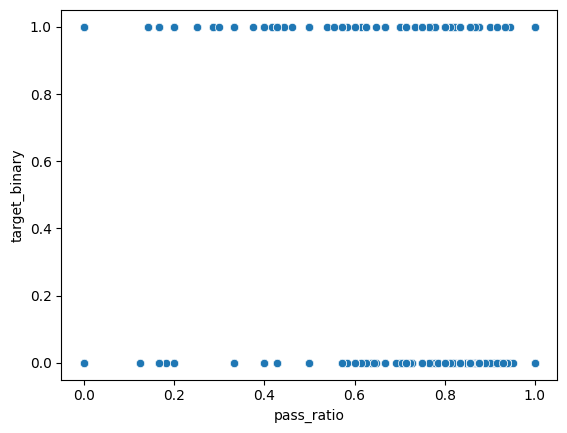

In [ ]:
sns.scatterplot(data=data_viz, x='pass_ratio', y='target_binary')

In [ ]:
import numpy as np

# Pass Efficiency = Approved / Enrolled
data_viz["pass_eff_1st"] = np.divide(
    data_viz["Curricular units 1st sem (approved)"],
    data_viz["Curricular units 1st sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 1st sem (approved)"], dtype=float),
    where=data_viz["Curricular units 1st sem (enrolled)"]!=0
)

data_viz["pass_eff_2nd"] = np.divide(
    data_viz["Curricular units 2nd sem (approved)"],
    data_viz["Curricular units 2nd sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 2nd sem (approved)"], dtype=float),
    where=data_viz["Curricular units 2nd sem (enrolled)"]!=0
)

data_viz["pass_eff_avg"] = (data_viz["pass_eff_1st"] + data_viz["pass_eff_2nd"]) / 2

# Credit Utilisation = Credited / Enrolled
data_viz["credit_util_1st"] = np.divide(
    data_viz["Curricular units 1st sem (credited)"],
    data_viz["Curricular units 1st sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 1st sem (credited)"], dtype=float),
    where=data_viz["Curricular units 1st sem (enrolled)"]!=0
)

data_viz["credit_util_2nd"] = np.divide(
    data_viz["Curricular units 2nd sem (credited)"],
    data_viz["Curricular units 2nd sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 2nd sem (credited)"], dtype=float),
    where=data_viz["Curricular units 2nd sem (enrolled)"]!=0
)

data_viz["credit_util_avg"] = (data_viz["credit_util_1st"] + data_viz["credit_util_2nd"]) / 2

# Exam Participation = Evaluated / Enrolled
data_viz["eval_rate_1st"] = np.divide(
    data_viz["Curricular units 1st sem (evaluations)"],
    data_viz["Curricular units 1st sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 1st sem (evaluations)"], dtype=float),
    where=data_viz["Curricular units 1st sem (enrolled)"]!=0
)

data_viz["eval_rate_2nd"] = np.divide(
    data_viz["Curricular units 2nd sem (evaluations)"],
    data_viz["Curricular units 2nd sem (enrolled)"],
    out=np.zeros_like(data_viz["Curricular units 2nd sem (evaluations)"], dtype=float),
    where=data_viz["Curricular units 2nd sem (enrolled)"]!=0
)

data_viz["eval_rate_avg"] = (data_viz["eval_rate_1st"] + data_viz["eval_rate_2nd"]) / 2

# Grade Efficiency = Grade / Credited
data_viz["grade_eff_1st"] = np.divide(
    data_viz["Curricular units 1st sem (grade)"],
    data_viz["Curricular units 1st sem (credited)"],
    out=np.zeros_like(data_viz["Curricular units 1st sem (grade)"], dtype=float),
    where=data_viz["Curricular units 1st sem (credited)"]!=0
)

data_viz["grade_eff_2nd"] = np.divide(
    data_viz["Curricular units 2nd sem (grade)"],
    data_viz["Curricular units 2nd sem (credited)"],
    out=np.zeros_like(data_viz["Curricular units 2nd sem (grade)"], dtype=float),
    where=data_viz["Curricular units 2nd sem (credited)"]!=0
)

data_viz["grade_eff_avg"] = (data_viz["grade_eff_1st"] + data_viz["grade_eff_2nd"]) / 2

# Improvement = 2nd sem approved - 1st sem approved
data_viz["improvement"] = data_viz["Curricular units 2nd sem (approved)"] - data_viz["Curricular units 1st sem (approved)"]


data_viz.replace([float("inf"), -float("inf")], 0, inplace=True)
data_viz.fillna(0, inplace=True)


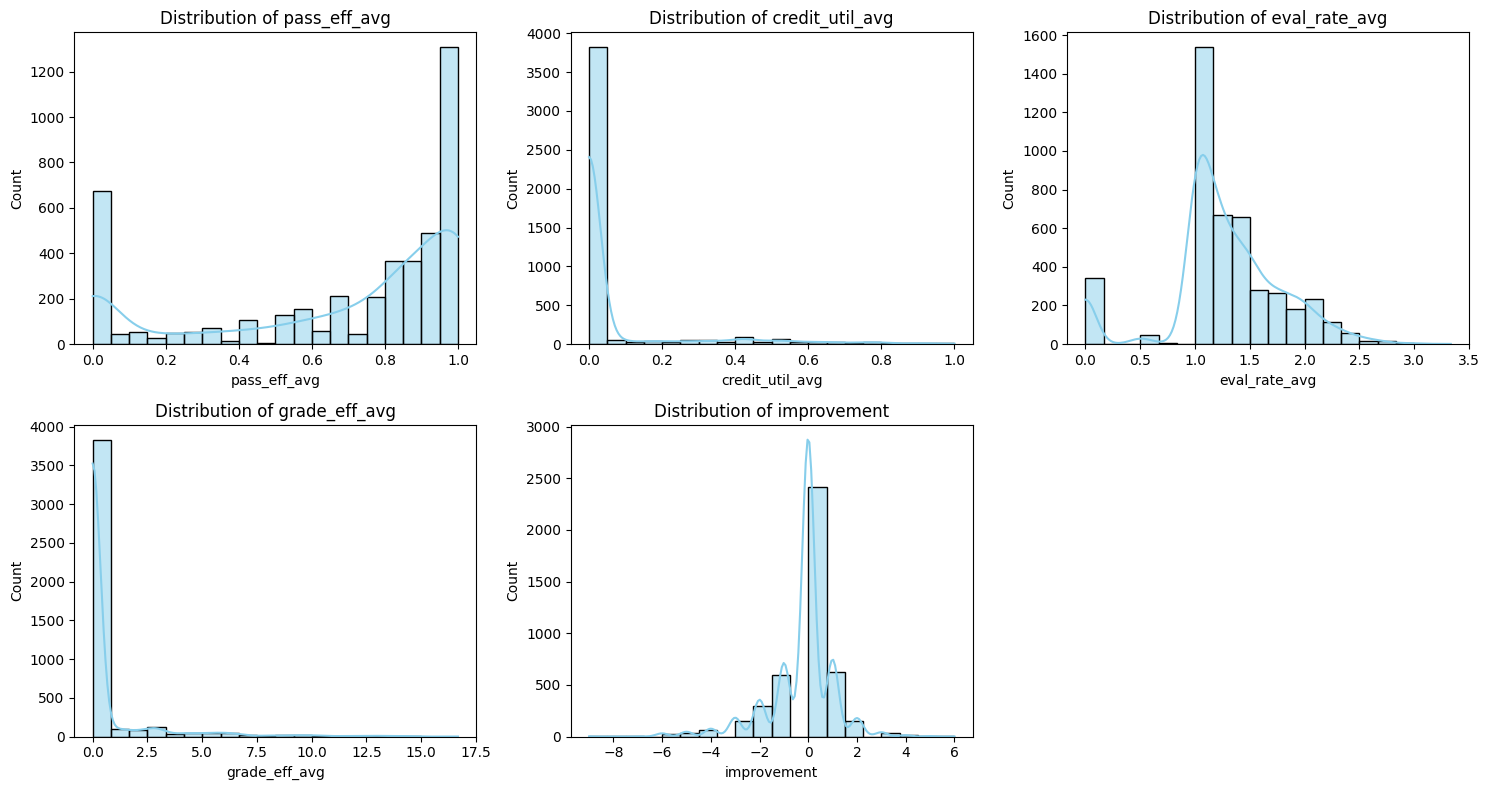

In [ ]:
new_features = ["pass_eff_avg", "credit_util_avg", "eval_rate_avg", "grade_eff_avg", "improvement"]

plt.figure(figsize=(15, 8))
for i, feature in enumerate(new_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data_viz[feature], bins=20, kde=True, color="skyblue")
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2273717652.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2273717652.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2273717652.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2273717652.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2273717652.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and wi

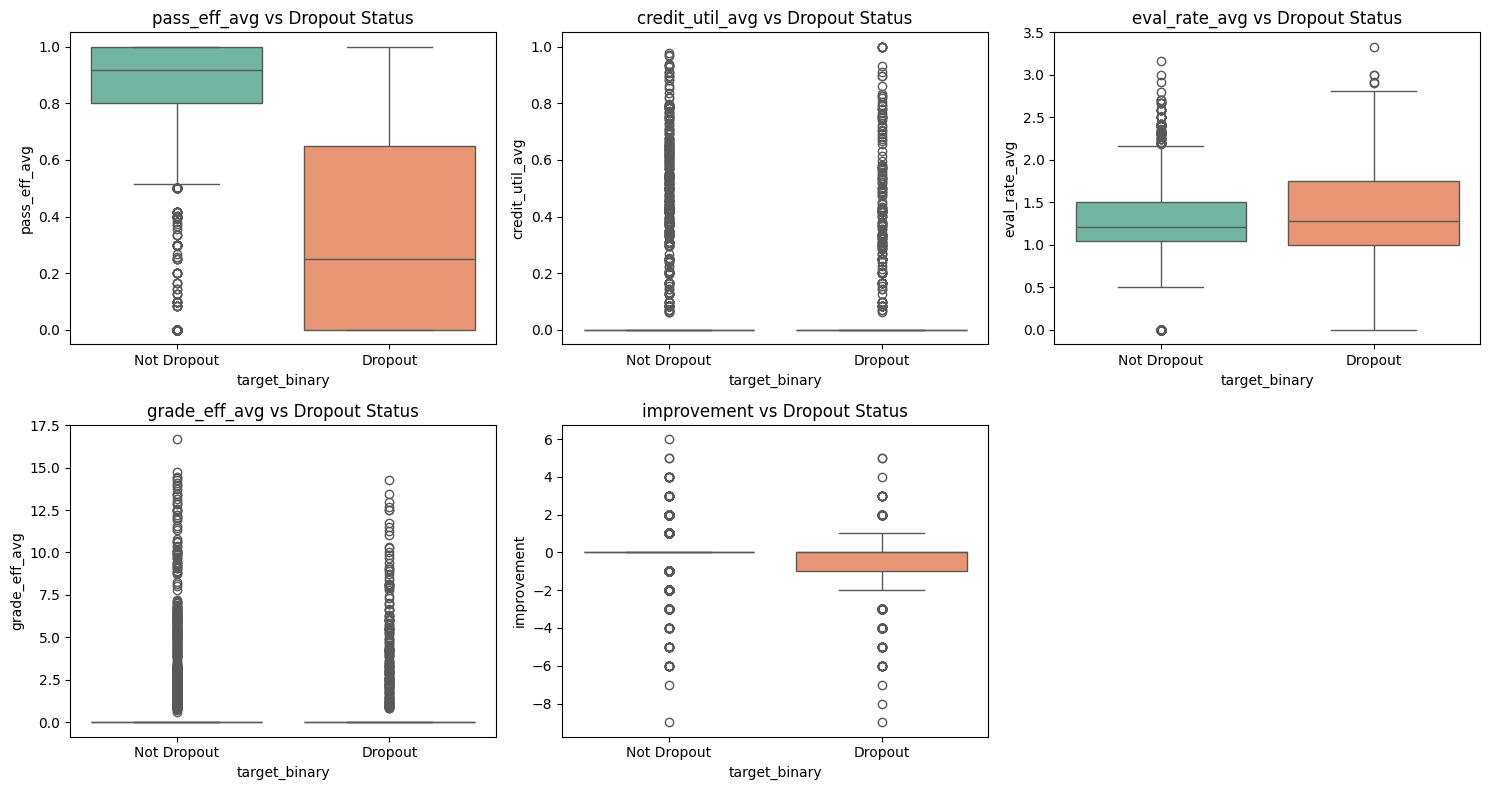

In [ ]:
plt.figure(figsize=(15, 8))
for i, feature in enumerate(new_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="target_binary", y=feature, data=data_viz, palette="Set2")
    plt.title(f"{feature} vs Dropout Status")
    plt.xticks([0,1], ["Not Dropout", "Dropout"])
plt.tight_layout()
plt.show()


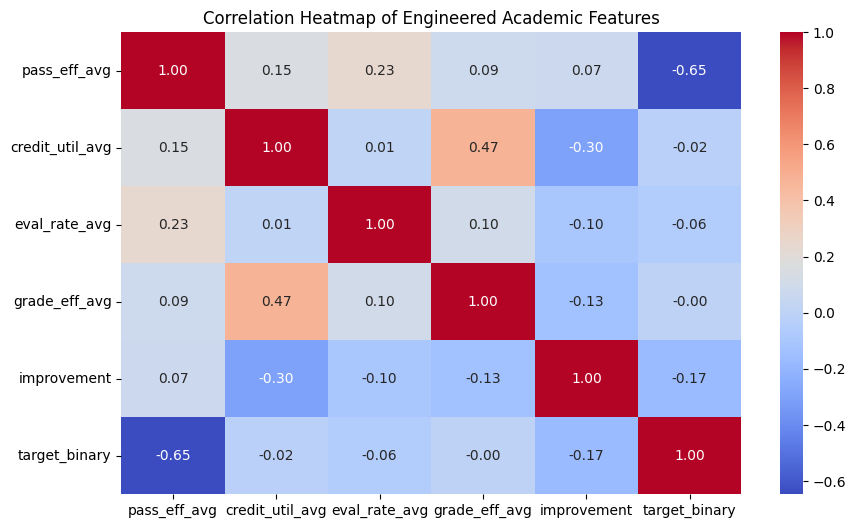

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data_viz[new_features + ["target_binary"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Engineered Academic Features")
plt.show()


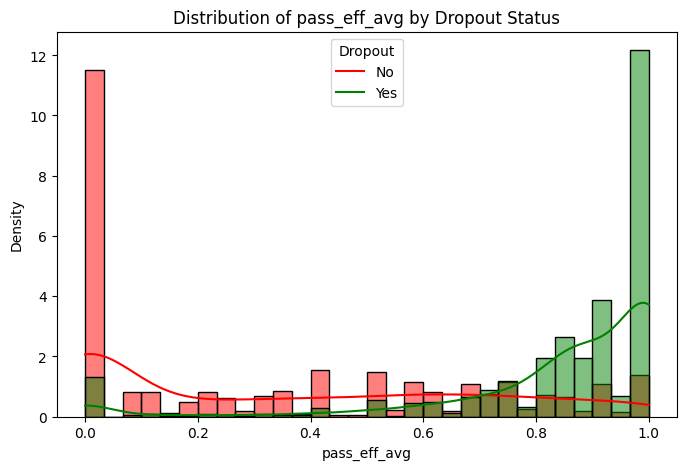

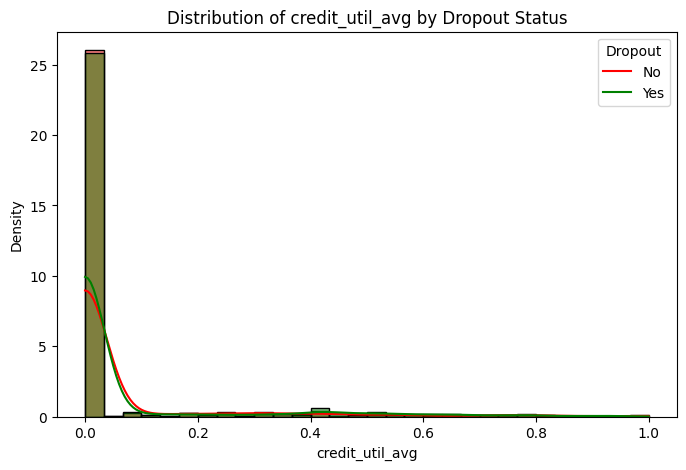

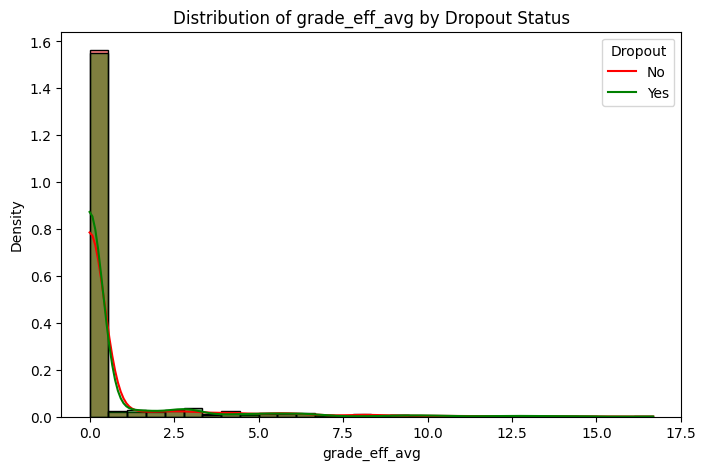

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dropout status is stored in column 'Target'
# Replace 'Target' with your actual column name if different
target_col = "Target"   # e.g., values: 'Dropout' / 'Enrolled' / 'Graduate'

# Pick only dropout vs non-dropout (binary classification)
data_viz['Dropout_Binary'] = data_viz[target_col].apply(lambda x: 1 if x == "Dropout" else 0)

# Features to visualize
features = ["pass_eff_avg", "credit_util_avg", "grade_eff_avg"]

for feat in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=data_viz, x=feat, hue="Dropout_Binary",
                 bins=30, kde=True, stat="density", common_norm=False,
                 palette={0:"green", 1:"red"})  # Green=not dropout, Red=dropout

    plt.title(f"Distribution of {feat} by Dropout Status")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend(title="Dropout", labels=["No", "Yes"])
    plt.show()


In [ ]:
import numpy as np

# --- Academic Efficiency Features ---
data_viz['pass_eff_sem1'] = np.where(
    data_viz['Curricular units 1st sem (evaluations)'] > 0,
    data_viz['Curricular units 1st sem (approved)'] / data_viz['Curricular units 1st sem (evaluations)'],
    np.nan
)

data_viz['pass_eff_sem2'] = np.where(
    data_viz['Curricular units 2nd sem (evaluations)'] > 0,
    data_viz['Curricular units 2nd sem (approved)'] / data_viz['Curricular units 2nd sem (evaluations)'],
    np.nan
)

data_viz['credit_util_sem1'] = np.where(
    data_viz['Curricular units 1st sem (enrolled)'] > 0,
    data_viz['Curricular units 1st sem (approved)'] / data_viz['Curricular units 1st sem (enrolled)'],
    np.nan
)

data_viz['credit_util_sem2'] = np.where(
    data_viz['Curricular units 2nd sem (enrolled)'] > 0,
    data_viz['Curricular units 2nd sem (approved)'] / data_viz['Curricular units 2nd sem (enrolled)'],
    np.nan
)

data_viz['eval_participation_sem1'] = np.where(
    data_viz['Curricular units 1st sem (enrolled)'] > 0,
    data_viz['Curricular units 1st sem (evaluations)'] / data_viz['Curricular units 1st sem (enrolled)'],
    np.nan
)

data_viz['eval_participation_sem2'] = np.where(
    data_viz['Curricular units 2nd sem (enrolled)'] > 0,
    data_viz['Curricular units 2nd sem (evaluations)'] / data_viz['Curricular units 2nd sem (enrolled)'],
    np.nan
)

data_viz['avg_grade'] = data_viz[['Curricular units 1st sem (grade)',
                                  'Curricular units 2nd sem (grade)']].mean(axis=1)

# --- Progression Features ---
data_viz['enrollment_change'] = np.where(
    data_viz['Curricular units 1st sem (enrolled)'] > 0,
    (data_viz['Curricular units 2nd sem (enrolled)'] - data_viz['Curricular units 1st sem (enrolled)']) /
    data_viz['Curricular units 1st sem (enrolled)'],
    np.nan
)

data_viz['approved_change'] = data_viz['Curricular units 2nd sem (approved)'] - data_viz['Curricular units 1st sem (approved)']
data_viz['grade_change'] = data_viz['Curricular units 2nd sem (grade)'] - data_viz['Curricular units 1st sem (grade)']

# Overall efficiency across both semesters
data_viz['overall_credit_util'] = np.where(
    (data_viz['Curricular units 1st sem (enrolled)'] + data_viz['Curricular units 2nd sem (enrolled)']) > 0,
    (data_viz['Curricular units 1st sem (approved)'] + data_viz['Curricular units 2nd sem (approved)']) /
    (data_viz['Curricular units 1st sem (enrolled)'] + data_viz['Curricular units 2nd sem (enrolled)']),
    np.nan
)

# --- Binary Flags ---
data_viz['never_enrolled_flag'] = (
    (data_viz['Curricular units 1st sem (enrolled)'] == 0) &
    (data_viz['Curricular units 2nd sem (enrolled)'] == 0)
).astype(int)

data_viz['failed_all_flag_sem1'] = (
    (data_viz['Curricular units 1st sem (enrolled)'] > 0) &
    (data_viz['Curricular units 1st sem (approved)'] == 0)
).astype(int)

data_viz['failed_all_flag_sem2'] = (
    (data_viz['Curricular units 2nd sem (enrolled)'] > 0) &
    (data_viz['Curricular units 2nd sem (approved)'] == 0)
).astype(int)

data_viz['inactive_semesters'] = (
    (data_viz['Curricular units 1st sem (enrolled)'] == 0).astype(int) +
    (data_viz['Curricular units 2nd sem (enrolled)'] == 0).astype(int)
)


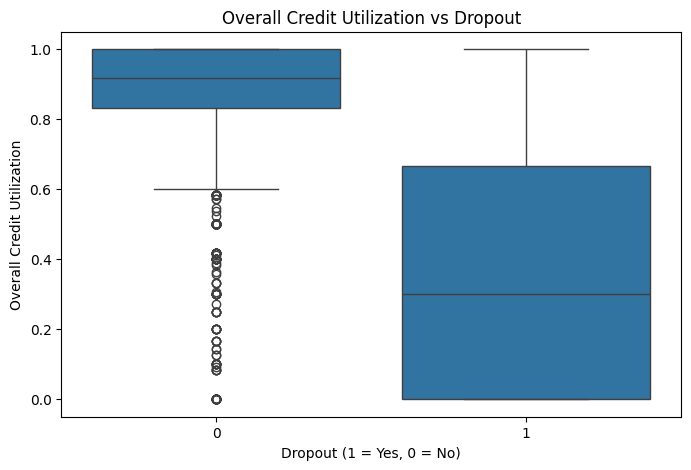

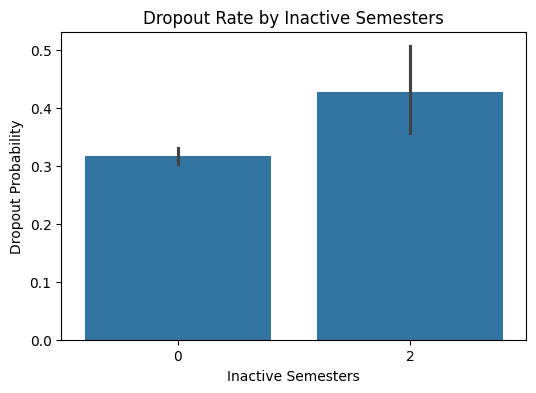

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example 1: Distribution of overall credit utilization
plt.figure(figsize=(8,5))
sns.boxplot(x='target_binary', y='overall_credit_util', data=data_viz)
plt.title("Overall Credit Utilization vs Dropout")
plt.xlabel("Dropout (1 = Yes, 0 = No)")
plt.ylabel("Overall Credit Utilization")
plt.show()

# Example 2: Dropout rate by inactive semesters
plt.figure(figsize=(6,4))
sns.barplot(x='inactive_semesters', y='target_binary', data=data_viz, estimator=np.mean)
plt.title("Dropout Rate by Inactive Semesters")
plt.xlabel("Inactive Semesters")
plt.ylabel("Dropout Probability")
plt.show()


              precision    recall  f1-score   support

           0       0.89      0.91      0.90       601
           1       0.80      0.75      0.77       284

    accuracy                           0.86       885
   macro avg       0.84      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885



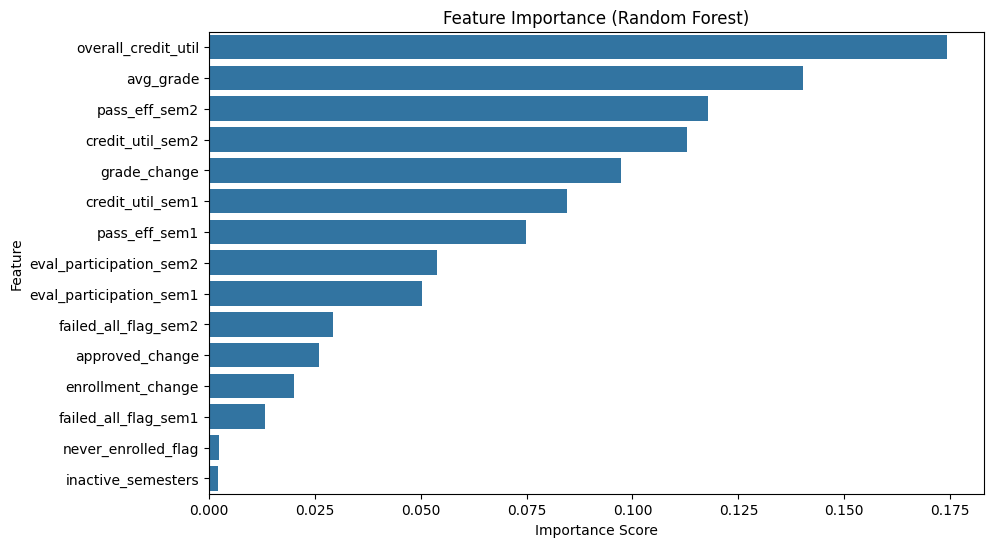

In [ ]:
"""
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select features (only the engineered + academic ones for now)
feature_cols = [
    'pass_eff_sem1', 'pass_eff_sem2',
    'credit_util_sem1', 'credit_util_sem2',
    'eval_participation_sem1', 'eval_participation_sem2',
    'avg_grade',
    'enrollment_change', 'approved_change', 'grade_change',
    'overall_credit_util',
    'never_enrolled_flag', 'failed_all_flag_sem1', 'failed_all_flag_sem2',
    'inactive_semesters'
]

X = data_viz[feature_cols]
y = data_viz['target_binary']

# Handle NaN (replace with -1 so the model can still train)
X = X.fillna(-1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
"""

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       601
           1       0.81      0.80      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885



/tmp/ipython-input-2300985077.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




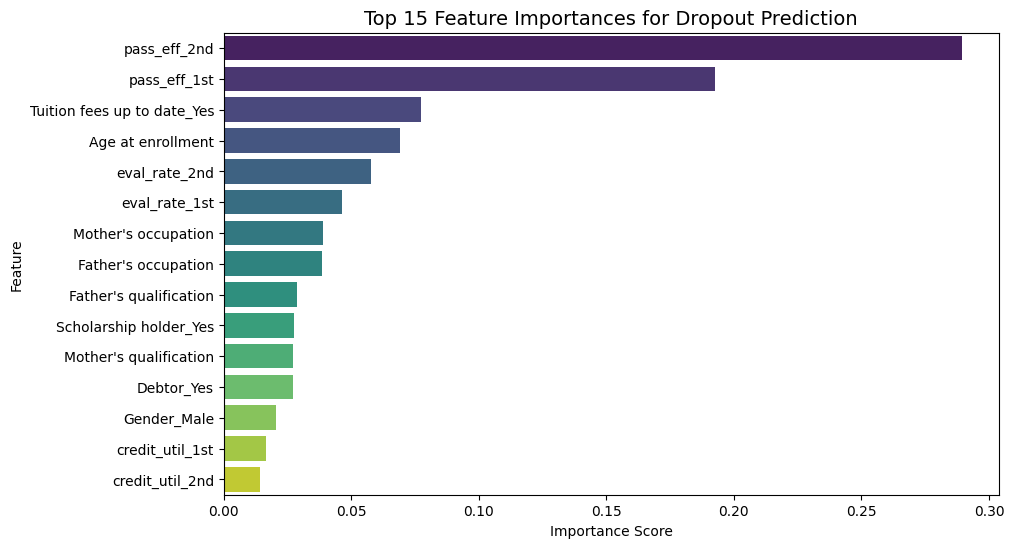

In [ ]:
"""
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- Feature set: engineered + selected raw ---
features = [
    # engineered
    "pass_eff_1st","pass_eff_2nd",
    "credit_util_1st","credit_util_2nd",
    "eval_rate_1st","eval_rate_2nd",


    # raw
    "Age at enrollment","Gender","Marital status","Daytime/evening attendance",
    "Previous qualification","Mother's qualification","Father's qualification",
    "Mother's occupation","Father's occupation","Debtor","Tuition fees up to date",
    "Scholarship holder","International"
]


X = data_viz[features]
y = data_viz['target_binary']

# Handle categoricals (quick one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RandomForest (baseline)
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


# Get feature importances from the trained model
importances = clf.feature_importances_
feature_names = X.columns

# Create a DataFrame for sorting
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 15 features
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(15), palette="viridis")
plt.title("Top 15 Feature Importances for Dropout Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
"""

Training Decision Tree...
Decision Tree Accuracy: 0.7774
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       601
           1       0.64      0.68      0.66       284

    accuracy                           0.78       885
   macro avg       0.75      0.75      0.75       885
weighted avg       0.78      0.78      0.78       885



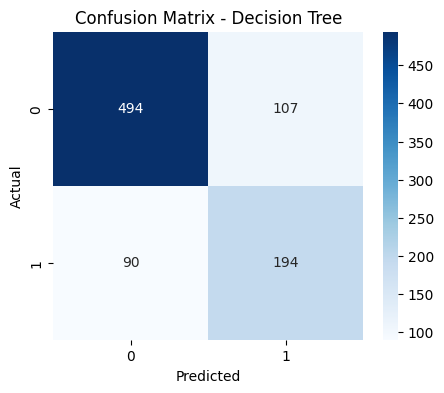

/tmp/ipython-input-2420278269.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




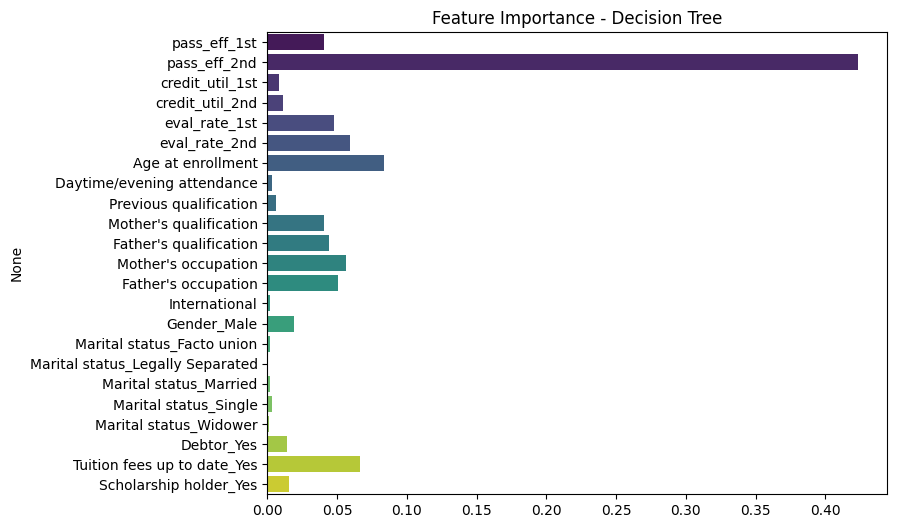

Training Random Forest...
Random Forest Accuracy: 0.8802
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.84      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



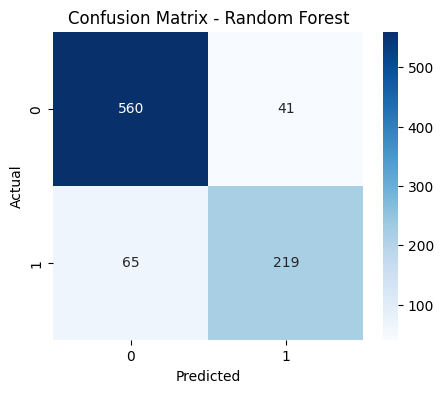

/tmp/ipython-input-2420278269.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




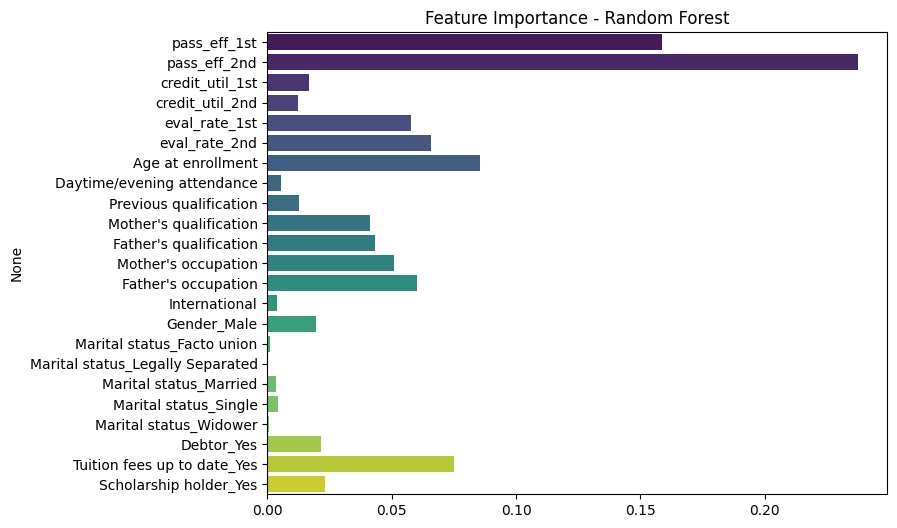

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[08:12:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




XGBoost Accuracy: 0.8859
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       601
           1       0.85      0.79      0.82       284

    accuracy                           0.89       885
   macro avg       0.87      0.86      0.87       885
weighted avg       0.88      0.89      0.88       885



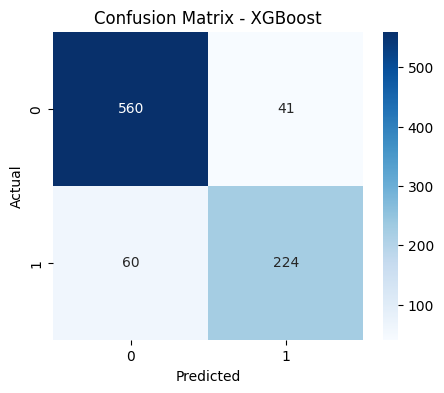

/tmp/ipython-input-2420278269.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




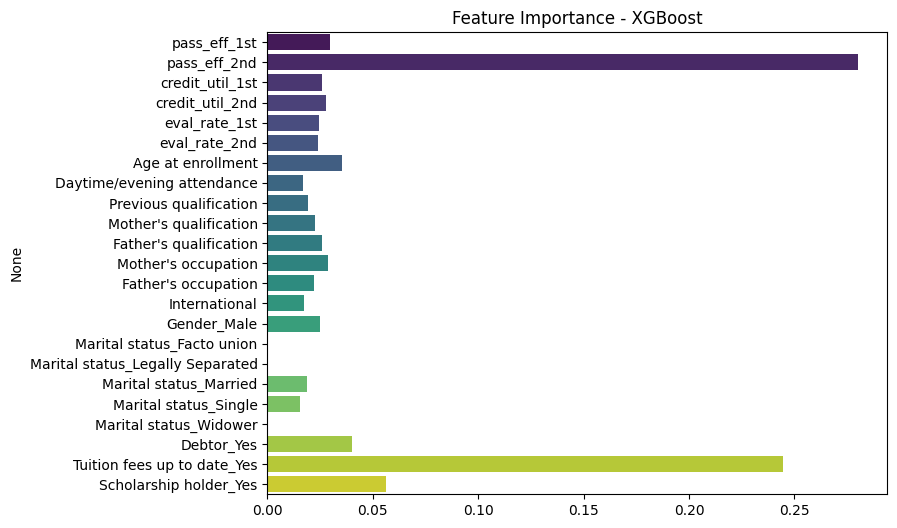

/tmp/ipython-input-2420278269.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




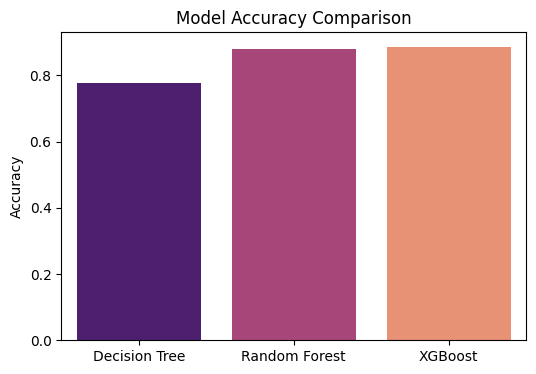

In [ ]:
"""
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Define models
# -----------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
}

results = {}

# -----------------------------
# Train & Evaluate each model
# -----------------------------
for name, model in models.items():
    print("="*50)
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Feature Importance (for tree-based models)
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(8,6))
        sns.barplot(x=model.feature_importances_, y=X_train.columns, palette="viridis")
        plt.title(f"Feature Importance - {name}")
        plt.show()

# -----------------------------
# Compare Accuracies
# -----------------------------
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="magma")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
"""

In [ ]:
"""

sample predictions

import pandas as pd

# Sample student data (adjust as needed)
sample_student = {
  # At-Risk Student (likely dropout)
        "pass_eff_1st": 0.85, "pass_eff_2nd": 0.80,
        "credit_util_1st": 0.82, "credit_util_2nd": 0.78,
        "eval_rate_1st": 0.88, "eval_rate_2nd": 0.85,
        "Age at enrollment": 18, "Gender": 0, "Marital status": 1,
        "Daytime/evening attendance": 1, "Previous qualification": 1,
        "Mother's qualification": 4, "Father's qualification": 4,
        "Mother's occupation": 2, "Father's occupation": 2,
        "Debtor": 1, "Tuition fees up to date": 0,
        "Scholarship holder": 0, "International": 0
}


sample_df = pd.DataFrame([sample_student])

# Make sure sample_df matches training columns
sample_df = sample_df.reindex(columns=X_train.columns, fill_value=0)

# Now prediction works
prediction = models["XGBoost"].predict(sample_df)
print("Prediction (0 = Continue, 1 = Dropout):", prediction[0])

"""




Prediction (0 = Continue, 1 = Dropout): 1


🔹 Training Decision Tree (baseline)...
Baseline Decision Tree Accuracy: 0.7774
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       601
           1       0.64      0.68      0.66       284

    accuracy                           0.78       885
   macro avg       0.75      0.75      0.75       885
weighted avg       0.78      0.78      0.78       885



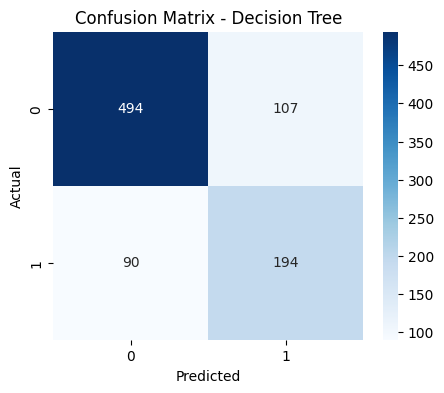

/tmp/ipython-input-2241475743.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




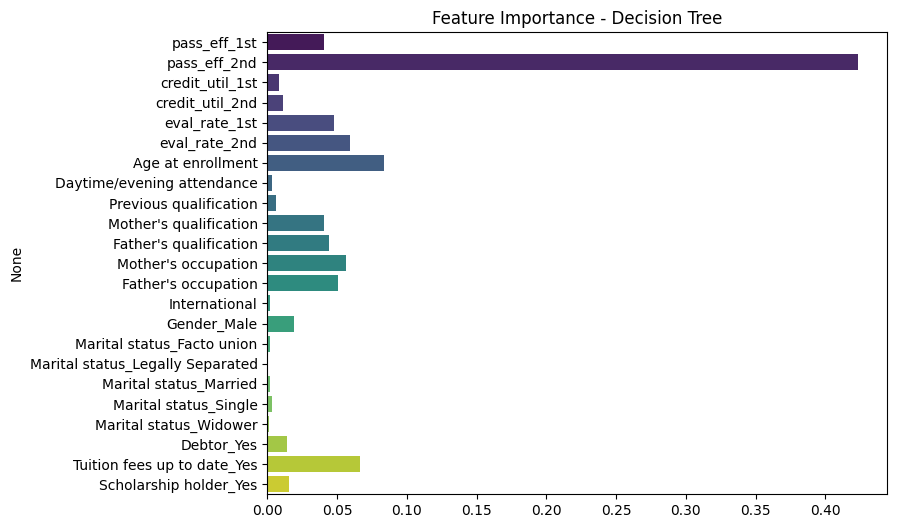

⚙️ Running GridSearchCV for Decision Tree...
✅ Best Params for Decision Tree: {'max_depth': 5, 'min_samples_split': 10}
✅ Best CV Accuracy for Decision Tree: 0.8488

🔹 Training Random Forest (baseline)...
Baseline Random Forest Accuracy: 0.8802
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.84      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



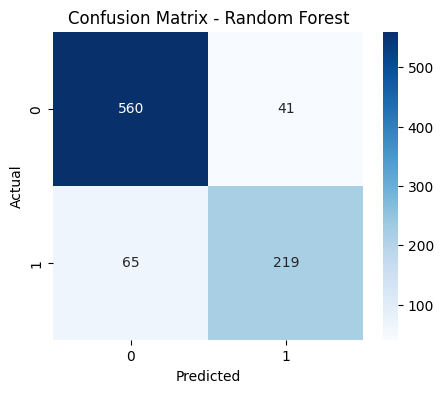

/tmp/ipython-input-2241475743.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




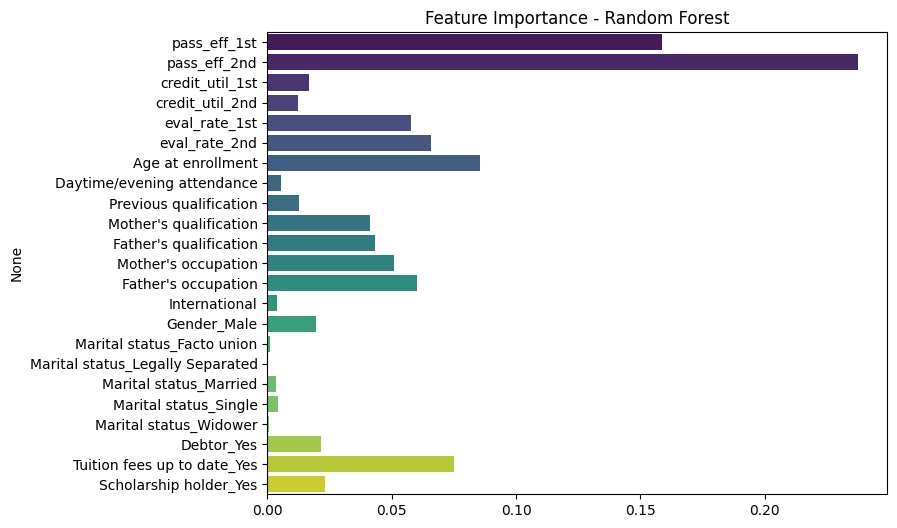

⚙️ Running GridSearchCV for Random Forest...
✅ Best Params for Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
✅ Best CV Accuracy for Random Forest: 0.8663

🔹 Training XGBoost (baseline)...
Baseline XGBoost Accuracy: 0.8859
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       601
           1       0.85      0.79      0.82       284

    accuracy                           0.89       885
   macro avg       0.87      0.86      0.87       885
weighted avg       0.88      0.89      0.88       885



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[08:32:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




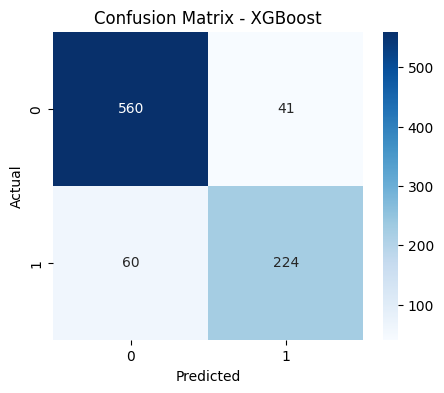

/tmp/ipython-input-2241475743.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




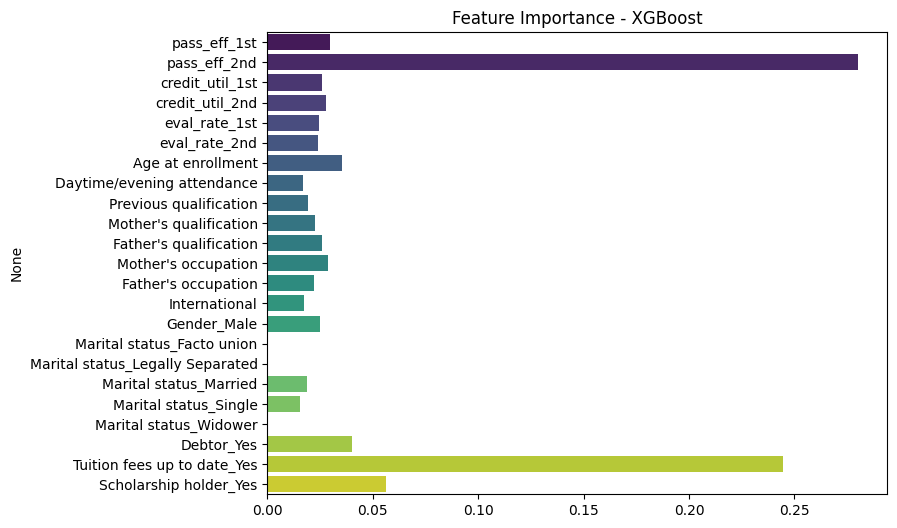

⚙️ Running GridSearchCV for XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[08:32:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/tmp/ipython-input-2241475743.py:79: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




✅ Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
✅ Best CV Accuracy for XGBoost: 0.8644



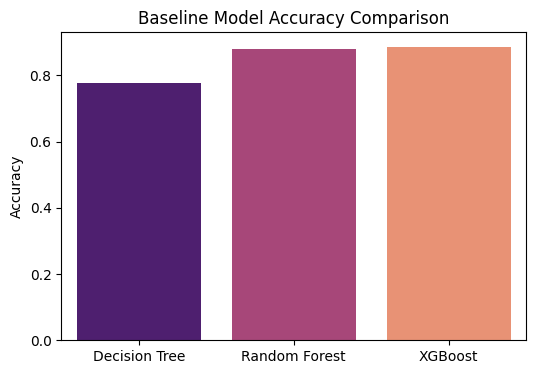

In [ ]:
"""
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Models + Param Grids
# -----------------------------
models = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [None, 5, 10, 20],
         "min_samples_split": [2, 5, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200],
         "max_depth": [None, 10, 20],
         "min_samples_split": [2, 5]}
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
        {"n_estimators": [100, 200],
         "max_depth": [3, 6, 10],
         "learning_rate": [0.01, 0.1, 0.2]}
    )
}

results = {}

# -----------------------------
# Train & Evaluate
# -----------------------------
for name, (model, param_grid) in models.items():
    print("="*60)
    print(f"🔹 Training {name} (baseline)...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Baseline {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Feature Importance (if available)
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(8,6))
        sns.barplot(x=model.feature_importances_, y=X_train.columns, palette="viridis")
        plt.title(f"Feature Importance - {name}")
        plt.show()

    # -----------------------------
    # GridSearchCV for Hyperparameter Tuning
    # -----------------------------
    print(f"⚙️ Running GridSearchCV for {name}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"✅ Best Params for {name}: {grid.best_params_}")
    print(f"✅ Best CV Accuracy for {name}: {grid.best_score_:.4f}")
    print()

# -----------------------------
# Compare Baseline Accuracies
# -----------------------------
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="magma")
plt.title("Baseline Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
"""

# Final mode+ gridsearchcv

🔹 Training Decision Tree (baseline)...
Baseline Decision Tree Accuracy: 0.7774
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       601
           1       0.64      0.68      0.66       284

    accuracy                           0.78       885
   macro avg       0.75      0.75      0.75       885
weighted avg       0.78      0.78      0.78       885



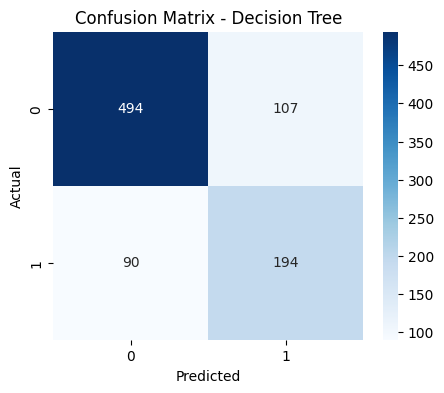

/tmp/ipython-input-3670209374.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




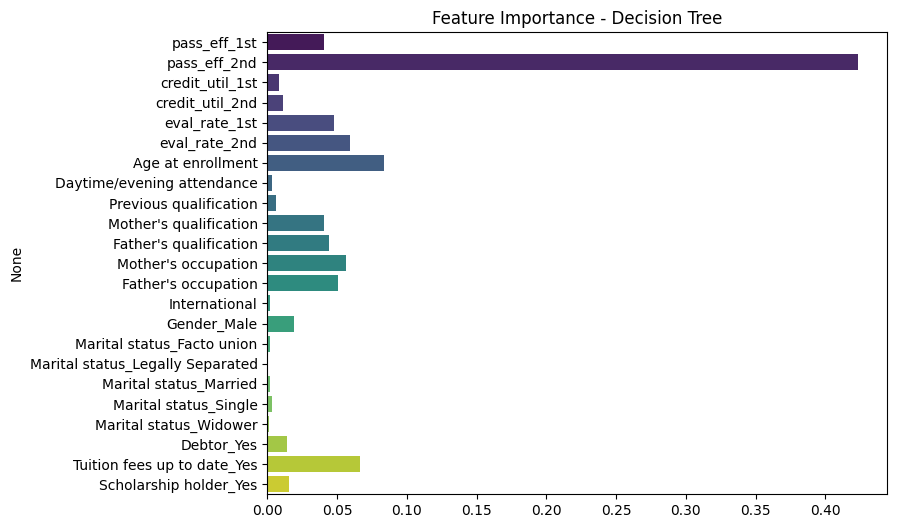

⚙️ Running GridSearchCV for Decision Tree...
✅ Best Params for Decision Tree: {'max_depth': 5, 'min_samples_split': 10}
✅ Best CV Accuracy for Decision Tree: 0.8488
💾 Saved best Decision Tree model to best_decision_tree.pkl

🔹 Training Random Forest (baseline)...
Baseline Random Forest Accuracy: 0.8802
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.84      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



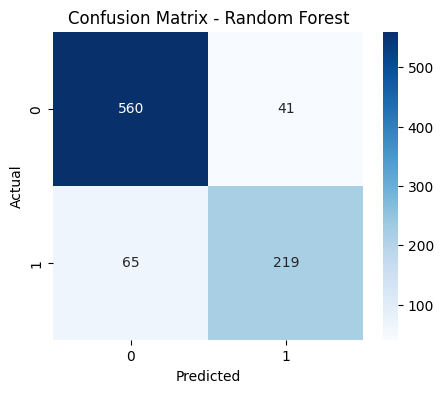

/tmp/ipython-input-3670209374.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




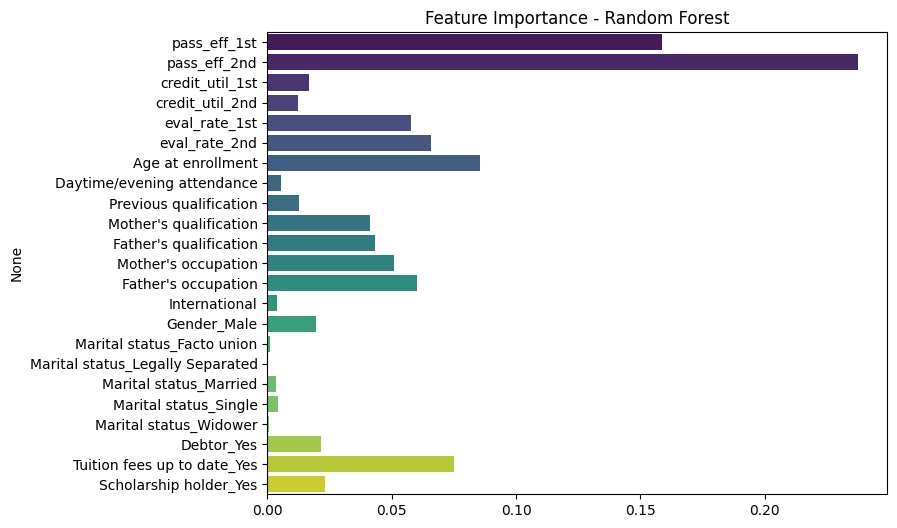

⚙️ Running GridSearchCV for Random Forest...
✅ Best Params for Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
✅ Best CV Accuracy for Random Forest: 0.8663
💾 Saved best Random Forest model to best_random_forest.pkl

🔹 Training XGBoost (baseline)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[08:37:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Baseline XGBoost Accuracy: 0.8859
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       601
           1       0.85      0.79      0.82       284

    accuracy                           0.89       885
   macro avg       0.87      0.86      0.87       885
weighted avg       0.88      0.89      0.88       885



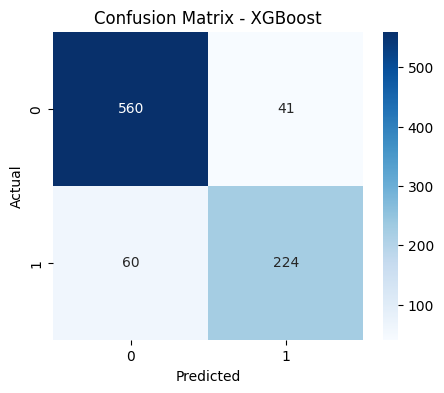

/tmp/ipython-input-3670209374.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




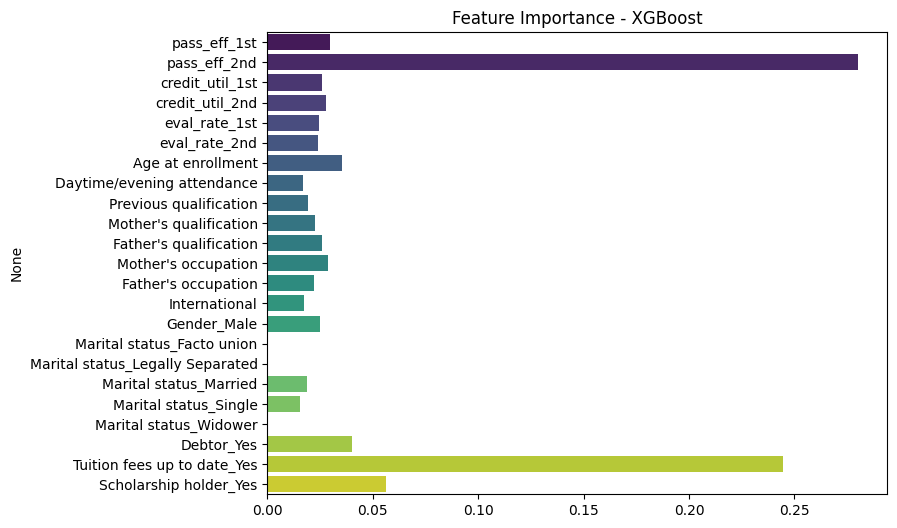

⚙️ Running GridSearchCV for XGBoost...
✅ Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
✅ Best CV Accuracy for XGBoost: 0.8644
💾 Saved best XGBoost model to best_xgboost.pkl



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[08:37:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/tmp/ipython-input-3670209374.py:88: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




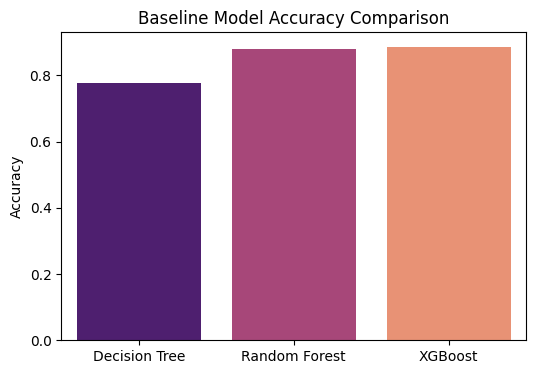

In [ ]:
"""
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# -----------------------------
# Models + Param Grids
# -----------------------------
models = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [None, 5, 10, 20],
         "min_samples_split": [2, 5, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 200],
         "max_depth": [None, 10, 20],
         "min_samples_split": [2, 5]}
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
        {"n_estimators": [100, 200],
         "max_depth": [3, 6, 10],
         "learning_rate": [0.01, 0.1, 0.2]}
    )
}

results = {}

# -----------------------------
# Train & Evaluate
# -----------------------------
for name, (model, param_grid) in models.items():
    print("="*60)
    print(f"🔹 Training {name} (baseline)...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Baseline {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Feature Importance (if available)
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(8,6))
        sns.barplot(x=model.feature_importances_, y=X_train.columns, palette="viridis")
        plt.title(f"Feature Importance - {name}")
        plt.show()

    # -----------------------------
    # GridSearchCV for Hyperparameter Tuning
    # -----------------------------
    print(f"⚙️ Running GridSearchCV for {name}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"✅ Best Params for {name}: {grid.best_params_}")
    print(f"✅ Best CV Accuracy for {name}: {grid.best_score_:.4f}")

    # -----------------------------
    # Save best model to pickle
    # -----------------------------
    best_model = grid.best_estimator_
    filename = f"best_{name.lower().replace(' ', '_')}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(best_model, f)
    print(f"💾 Saved best {name} model to {filename}\n")

# -----------------------------
# Compare Baseline Accuracies
# -----------------------------
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="magma")
plt.title("Baseline Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
"""


# Saving model using pickle

In [ ]:
# with open("best_xgboost.pkl", "rb") as f:
#     best_xgb = pickle.load(f)

# y_pred = best_xgb.predict(X_test)


In [ ]:
"""
from google.colab import drive
import os
import pickle

# Mount Google Drive
drive.mount('/content/drive')

# Define path inside your Google Drive
save_path = "/content/drive/MyDrive/model_results"
os.makedirs(save_path, exist_ok=True)

# --- inside your loop after finding best_model ---
filename = os.path.join(save_path, f"best_{name.replace(' ', '_').lower()}.pkl")
with open(filename, "wb") as f:
    pickle.dump(best_model, f)

print(f"✅ Saved {name} model to: {filename}")
"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved XGBoost model to: /content/drive/MyDrive/model_results/best_xgboost.pkl
